In [1]:
import uproot
import awkward as ak
import numpy as np

# Open File

In [2]:
file = uproot.open("/lstr/sahara/act/data/DAOD_PHYSLITE.37621365._000015.pool.root.1")
#file = uproot.open("SMHiggsToZZTo4L.root")

## Get to know your data
MC simulation electroweak boson nominal samples from the ATLAS experiment. 

### Exercise 1:

What objects are in this file? What's the name of the ttree?

In [3]:
file.keys()

['##Params;3',
 '##Params;2',
 '##Shapes;3',
 '##Shapes;2',
 '##Links;3',
 '##Links;2',
 'MetaData;1',
 'MetaDataHdr;1',
 'MetaDataHdrForm;1',
 'CollectionTree;1',
 'POOLContainer;1',
 'POOLContainerForm;1',
 'POOLCollectionTree;1']

In [4]:
# Access ttree
tree = file["CollectionTree"]  

In [5]:
# we can see the list of branch names using tree.keys()
#tree.keys()

In [6]:
# or you can use tree.show() to see more information on the branches
#tree.show()

### Exercise 2

How many branches are in this ttree?
To answer this, you may want to use `len(...)`. 

In [7]:
xTree = len(tree)
xKeys = len(tree.keys())  

print("len of tree:", xTree, " and tree.keys():", xKeys)

len of tree: 1360  and tree.keys(): 1511


### Exercise 3

We can read TBranches as arrays using `tree.arrays(["insert_list_of_branch_names_here"])`. Fill in the blanks associated with Muons (we want charge, pt, eta, phi).

In [8]:
Electrons = tree.arrays(["AnalysisElectronsAuxDyn.charge", "AnalysisElectronsAuxDyn.pt","AnalysisElectronsAuxDyn.eta", "AnalysisElectronsAuxDyn.phi","AnalysisElectronsAuxDyn.m"])
Muons = tree.arrays(["AnalysisMuonsAuxDyn.charge", "AnalysisMuonsAuxDyn.pt", "AnalysisMuonsAuxDyn.eta", "AnalysisMuonsAuxDyn.phi"])  

### Exercise 4
How many events are in this tree?

In [9]:
num_events = len(Muons)  
print("Number of events:", num_events)

Number of events: 200000


### Exercise 5

How many electrons are in the 80th event? What are their charges? How many muons are in the 34th event? What are their pt? 

In [10]:
Electrons["AnalysisElectronsAuxDyn.charge"][79]

<Array [1, -1, -1, 1] type='4 * float32'>

In [11]:
Muons["AnalysisMuonsAuxDyn.pt"][199999]  

<Array [2.9e+05, 5.67e+04] type='2 * float32'>

To make our lives easier, [ak.zip](https://awkward-array.org/doc/main/reference/generated/ak.zip.html) combines arrays into a single structure as a collection of records. 

In [12]:
e = ak.zip({
    "pt" : Electrons["AnalysisElectronsAuxDyn.pt"],
    "eta" : Electrons["AnalysisElectronsAuxDyn.eta"],
    "phi" : Electrons["AnalysisElectronsAuxDyn.phi"],
    "mass" : Electrons["AnalysisElectronsAuxDyn.m"],
    "charge" : Electrons["AnalysisElectronsAuxDyn.charge"]
})
mu = ak.zip({
    "pt" : Muons["AnalysisMuonsAuxDyn.pt"],
    "eta" : Muons["AnalysisMuonsAuxDyn.eta"],
    "phi" : Muons["AnalysisMuonsAuxDyn.phi"],
    "charge" : Muons["AnalysisMuonsAuxDyn.charge"]
})

What's the total number of electrons in the data set? What about muons? The function [ak.num](https://awkward-array.org/doc/main/reference/generated/ak.num.html) may help.

In [13]:
num_e = len(ak.num(e))  
num_mu = len(ak.num(mu))  
print("Total number of electrons: ", num_e)
print("Total number of muons: ", num_mu)

Total number of electrons:  200000
Total number of muons:  200000


# Ready for analysis

Now we are going to calculate the tranverse momentum components and energy for electrons, using the above.  

In [14]:
#  Momentum components
def Px(pt, phi):
    return pt*np.cos(phi)

def Py(pt,phi):
    return pt*np.sin(phi)

def Pz(pt,eta):
    return pt*np.sinh(eta)

def E(pt, eta, m):
    return np.sqrt(
        pt**2 * np.cosh(eta)**2 + m**2
    )

e_px = Px(e.pt,e.phi)
e_py = Py(e.pt,e.phi)
e_pz = Pz(e.pt,e.eta)
e_E = E(e.pt,e.eta,e.mass)

print(e_px[62][0])
# for index in range(0, 100):
    # print("E_px: ", e_px[index]," E_py: ", e_py[index]," E_pz: ", e_pz[index]," E_E: ", e_E[index])

33514.906


The invariant mass of two oppositely charged leptons is defined as:
\begin{equation}
m_0 = \sqrt{(\sum{E})^2-(\sum{p_x})^2-(\sum{p_y})^2-(\sum{p_z})^2}
\end{equation}


### Exercise 6

Create a function, using the functions above for energy and momentum components, that calculates the invariant mass in GeV. Calculate the invariant mass of the electron pair in the 63rd event.

In [15]:
def calc_invm(p1, p2):
    sumpx = Px(p1.pt, p1.phi) + Px(p2.pt, p2.phi)  
    sumpy = Py(p1.pt, p1.phi) + Py(p2.pt, p2.phi)
    sumpz = Pz(p1.pt, p1.phi) + Pz(p2.pt, p2.phi)   
    sumE = E(p1.pt, p1.eta, p1.mass) + E(p2.pt, p2.eta, p2.mass) 
    
    invm = np.sqrt(sumpx**2 + sumpy**2 + sumpz**2 + sumE**2)  
    return invm/1000.0 # in GeV

print("first try = 183.76104251683347")
print("second (Correct) try =", calc_invm(e[62][0], e[62][0])) 

first try = 183.76104251683347
second (Correct) try = 265.2550619026593


## Data Selection

As shown in Frank's workshop, we can mask awkward arrays to apply cuts for data selection. 

### Exercise 7

Make a selection of events with more than two electrons and with electron pt greater than 25 GeV [data set is in MeV].

This should leave you with a total of 2130 electrons.

In [16]:
# Setup min pt
minimum_pt = 25000 # in MeV 

# Start creating a cut
e_num_cut = ak.num(e.charge, axis=1) >= 2
pt_cut = e.pt > minimum_pt 
e_cut = pt_cut & e_num_cut # final cut

# apply final cut to electrons
cleaned_e = e[e_cut]

num_of_objects_fitting_mask = ak.num(cleaned_e)
num_filtered_electrons = ak.sum(num_of_objects_fitting_mask)
print("Number of electrons that passed selection:", num_filtered_electrons)

Number of electrons that passed selection: 2130


### Exercise 8

Of these events, we want to calculate the invariant mass of oppositely charged pairs. However, some events include 3 electrons perhaps with charges [1,-1,1], which in this case have 2 possible pairings. 

How many events contain more than 2 electrons? What are their indices?

The function [ak.where](https://awkward-array.org/doc/main/reference/generated/ak.where.html) and [ak.combinations](https://awkward-array.org/doc/main/reference/generated/ak.combinations.html) may come in handy.

In [17]:
lengths = ak.num(cleaned_e)
indices = ak.where(lengths > 2)[0].tolist()
# indices

In [18]:
cleaned_e[15180]

<Array [{pt: 1.11e+06, eta: 0.73, ...}, ...] type='3 * {pt: float32, eta: f...'>

In [19]:
h = ak.combinations(cleaned_e, 2, axis = 1)
h.type

# e1, e2 = ak.unzip(h)

ArrayType(ListType(RecordType([RecordType([NumpyType('float32'), NumpyType('float32'), NumpyType('float32'), NumpyType('float32'), NumpyType('float32')], ['pt', 'eta', 'phi', 'mass', 'charge']), RecordType([NumpyType('float32'), NumpyType('float32'), NumpyType('float32'), NumpyType('float32'), NumpyType('float32')], ['pt', 'eta', 'phi', 'mass', 'charge'])], None)), 200000, None)

# Homework Assignment

## Problem 1
Continuing on with the workshop, the goal of this assignment is to plot the Z mass using the tools we've learned from the awkward library. Z decays into electron-positron or muon-antimuon. 
<div style="display: flex;">
    <img src="https://atlas.physicsmasterclasses.org/zpath_files/img/highslide/feynman/Z_ElectronPositron.png" style="height:300px; margin-right: 10px;">
    <img src="https://atlas.physicsmasterclasses.org/zpath_files/img/highslide/feynman/Z_MyonAntimyon.png" style="height:300px;">
</div>

1. Create a function `selection_calc(lepton)` that applies the selection we've made above, obtains oppositely charged lepton pairs, and calculates the invariant mass. We want events with oppositely charged lepton pairs with pt > 25 GeV. \
    __hint__: Re-use the functions already built in class. \
    __note__: The data does not contain Muon mass, so you can assume all muons have mass = 0 (you might need to adjust the function `calc_invm` for this) 
   
2. Plot the invariant mass of both electron and muon pairs on the same histogram. Find the peak of the histogram and return the Z mass.

Z mass =  91.188 [GeV]


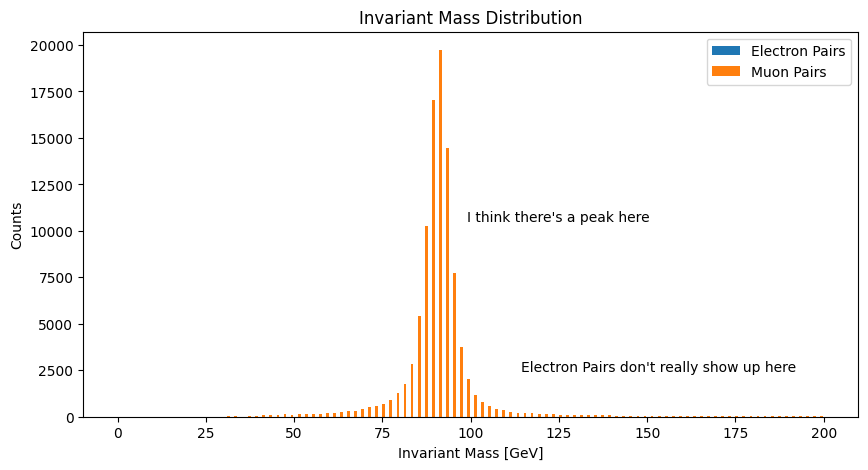

In [82]:
import matplotlib.pyplot as plt
import numpy as np
import particle, hepunits

zmass = particle.Particle.findall("Z0")[0].mass / hepunits.GeV
print("Z mass = ", zmass,"[GeV]")

def invar_mass_calc(lep1, lep2):
    invar_mass = np.sqrt(
        2 * lep1.pt * lep2.pt * (np.cosh(lep1.eta - lep2.eta) - np.cos(lep1.phi - lep2.phi))
    )
    return invar_mass

def calc_invm(p1, p2):
    sumpx = Px(p1.pt,p1.phi) + Px(p2.pt,p2.phi)
    sumpy = Py(p1.pt, p1.phi) + Py(p2.pt,p2.phi)
    sumpz = Pz(p1.pt,p1.eta) + Pz(p2.pt,p2.eta) 
    try:
        sumE = E(p1.pt,p1.eta,p1.mass) + E(p2.pt,p2.eta,p2.mass)
        invm = np.sqrt(sumpx**2 + sumpy**2 + sumpz**2 + sumE**2)  
    except AttributeError:
        sumE = E(p1.pt,p1.eta,0) + E(p2.pt,p2.eta,0)
        invm = np.sqrt(sumE**2 - sumpx**2 - sumpy**2 - sumpz**2)
    return invm/1000.0 

def selection_calc(lep, min_pt=25000): 
    # start creating a cut
    pt_cut = lep.pt > min_pt 
    lep = lep[pt_cut] # apply the pt cut

    # ensure 2 leptons per event
    lep_num_cut = ak.num(lep) == 2
    lep = lep[lep_num_cut]

    # create leptop pairs
    lep1, lep2 = ak.unzip(ak.combinations(lep,2))
    
    opp_charge_cut = (lep1.charge != lep2.charge)
    lep1, lep2 = lep1[opp_charge_cut], lep2[opp_charge_cut]

    return lep1, lep2


e1, e2 = selection_calc(e)
# print(len(e1)) # = 173
# print(len(e2)) # = 173
mu1, mu2 = selection_calc(mu)
# print(len(mu1)) # = 100092
# print(len(mu2)) # = 100092

# e_mass = invar_mass_calc(e1, e2) / 1000
# mu_mass = invar_mass_calc(mu1, mu2) / 1000
e_mass = calc_invm(e1,e2)
mu_mass = calc_invm(mu1,mu2)

# print("Electron Mass Sample:", ak.flatten(e_mass)[:10])
# print("Muon Mass Sample:", ak.flatten(mu_mass)[:10])

# Size of each array
# print(len(e_mass)) # = 173
# print(len(mu_mass)) # = 100092
# print(ak.ravel(e_mass))

# Plot histogram
plt.figure(figsize=(10,5))
# hist_data.fill(ak.flatten(e_mass))
# hist_data.fill(ak.flatten(mu_mass))
# print(hist_data.type())
plt.xlabel("Invariant Mass [GeV]")
plt.ylabel("Counts")
plt.title("Invariant Mass Distribution")
plt.figtext(0.6, 0.5, "I think there's a peak here", ha="center", fontsize=10)
plt.figtext(0.7, 0.2, "Electron Pairs don't really show up here", ha="center", fontsize=10)
plt.hist((ak.flatten(e_mass),ak.flatten(mu_mass)),bins=100, range=(0,200),histtype='bar',label=["Electron Pairs", "Muon Pairs"])
plt.legend()
plt.show()


## Problem 2

Now you're on your own! We will make selections used for top quark mass calculation, using ATLAS ttbar mc sample, `/lstr/sahara/act/data/DAOD_PHYSLITE.37620644._000012.pool.root.1`.

1. Make a selection of events that have atleast one lepton with pt > 30GeV and abs(eta) < 2.1 , and at least four jets. The jets should also have pt >25 GeV and abs(eta) < 2.4. How many events were selected? Plot distribution plots to check selection.
 
2. Now let's check jet quality. The btag discriminant is defined as :
   \begin{equation}
   D_{DL1} = \log\left(\frac{p_b}{f_c \cdot p_c + (1-f_c) \cdot p_u}\right)
   \end{equation}
   where $p_b, p_c, p_u$ are the fields labeled `BTaggingz_AntiKt4EMPFlowAuxDyn.DL1dv01_pb`, `BTagging_AntiKt4EMPFlowAuxDyn.DL1dv01_pc`, `BTagging_AntiKt4EMPFlowAuxDyn.DL1dv01_pu`, and $f_c = 0.018$. Calculate the Btag discriminant of the selected jets.

3. A jet is considered as b-tagged if the $D_{DL1}$ variable is above threshold. The threshold value for 77% efficiency is `2.456`. Make another selection of events that have at least two b-tagged jets. How many events were selected? Plot distribution plots to check selection.

__Hint__: [ak.any(...)](https://awkward-array.org/doc/main/reference/generated/ak.any.html) can help.

len of tree: 1427  and tree.keys(): 1590
Total number of electrons:  160000
Total number of muons:  160000
Total number of jets:  160000
Length of selected electrons: 452
Length of selected muons: 66158
Length of selected jets: 157642
sel_e.pt:  [33.8, 31.8, 56.6, 40.6, 52.3, 30.3, ..., 54.5, 32.2, 49.8, 75.4, 30.3, 30.8]
sel_m.pt:  [108, 54, 74.4, 49.2, 53.9, 46.3, 62.1, ..., 74.2, 105, 89.3, 156, 49.8, 77.9]
sel_j.pt:  [48, 27.1, 26.7, 116, 91.7, 39, 34.1, ..., 60.1, 100, 65, 59.4, 48.6, 32.7]


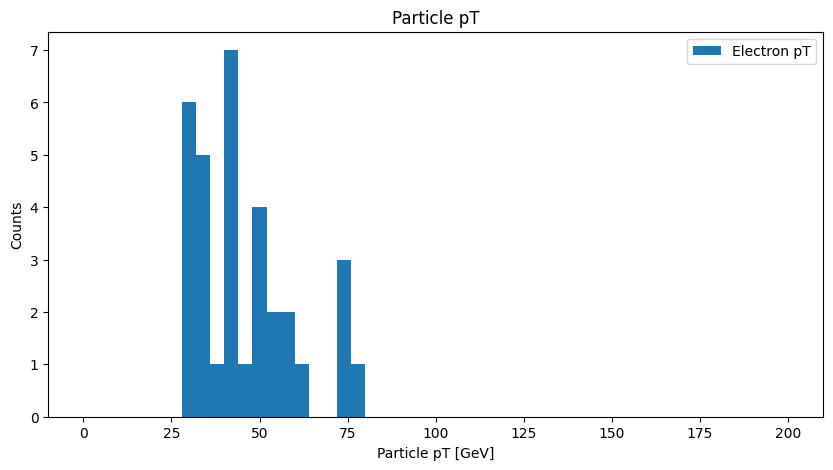

In [94]:
import hist
from hist import Hist
import matplotlib.pyplot as plt
import numpy as np
import particle, hepunits

file_n2 = uproot.open("/lstr/sahara/act/data/DAOD_PHYSLITE.37620644._000012.pool.root.1")
file_n2.keys()
t = file_n2["CollectionTree"]
xTree = len(t)
xKeys = len(t.keys())  
print("len of tree:", xTree, " and tree.keys():", xKeys)

# from t.keys(); Only AnalysisSiHitElectronsAuxDyn, no AnalysisElectronsAuxDyn? 
elecs = t.arrays(["AnalysisSiHitElectronsAuxDyn.charge", "AnalysisSiHitElectronsAuxDyn.pt","AnalysisSiHitElectronsAuxDyn.eta", "AnalysisSiHitElectronsAuxDyn.phi","AnalysisSiHitElectronsAuxDyn.m"])
muons = t.arrays(["AnalysisMuonsAuxDyn.charge", "AnalysisMuonsAuxDyn.pt", "AnalysisMuonsAuxDyn.eta", "AnalysisMuonsAuxDyn.phi"])  
jets = t.arrays(["AnalysisJetsAuxDyn.pt","AnalysisJetsAuxDyn.eta", "AnalysisJetsAuxDyn.phi", "AnalysisJetsAuxDyn.m"])

# for i in range(0,100):
#     print(Electrons["AnalysisSiHitElectronsAuxDyn.charge"][i])
# so we do have some in here...

es = ak.zip({
    "pt" : elecs["AnalysisSiHitElectronsAuxDyn.pt"],
    "eta" : elecs["AnalysisSiHitElectronsAuxDyn.eta"],
    "phi" : elecs["AnalysisSiHitElectronsAuxDyn.phi"],
    "mass" : elecs["AnalysisSiHitElectronsAuxDyn.m"],
    "charge" : elecs["AnalysisSiHitElectronsAuxDyn.charge"]
})
ms = ak.zip({
    "pt" : muons["AnalysisMuonsAuxDyn.pt"],
    "eta" : muons["AnalysisMuonsAuxDyn.eta"],
    "phi" : muons["AnalysisMuonsAuxDyn.phi"],
    "charge" : muons["AnalysisMuonsAuxDyn.charge"]
})
js = ak.zip({
    "pt" : jets["AnalysisJetsAuxDyn.pt"],
    "eta" : jets["AnalysisJetsAuxDyn.eta"],
    "phi" : jets["AnalysisJetsAuxDyn.phi"],
    "mass" : jets["AnalysisJetsAuxDyn.m"],
})

num_e = len(ak.num(es))  
num_mu = len(ak.num(ms))
num_jets = len(ak.num(js))
print("Total number of electrons: ", num_e)
print("Total number of muons: ", num_mu)
print("Total number of jets: ", num_jets)

def lep_selec_calc(lep, min_lep_pt=30000, max_lep_eta=2.1): 
    # Lepton Cuts
    ## Lepton Count Cut: 1 lepton/event
    lep_num_cut = ak.num(lep) == 1
    lep = lep[lep_num_cut]
    ## Lepton pT Cut
    lep_pt_cut = lep.pt > min_lep_pt 
    lep = lep[lep_pt_cut] # apply the pt cut
    ## Lepton Eta Cut
    lep_eta_cut = abs(lep.eta) < max_lep_eta
    lep = lep[lep_eta_cut]
    return lep

def jet_selec_calc(jet, min_jet_pt=25000, max_jet_eta=2.4): 
    # Jet Cuts
    ## Jet Count Cut: at least 4 Jets/event
    jet_num_cut = ak.num(jet) >= 4
    jet = jet[jet_num_cut]
    ## Jet pT Cut
    jet_pt_cut = jet.pt > min_jet_pt 
    jet = jet[jet_pt_cut] # apply the pt cut
    ## Jet Eta Cut
    jet_eta_cut = abs(jet.eta) < max_jet_eta
    jet = jet[jet_eta_cut]

    # Since we're looking for AT LEAST 4 jets, we might find more
    # So no need to make pairs or sets
    return jet

sel_e = lep_selec_calc(es, 30000, 2.1)
print("Length of selected electrons:", len(sel_e))

sel_m = lep_selec_calc(ms, 30000, 2.1)
print("Length of selected muons:", len(sel_m))

sel_j = jet_selec_calc(js, 25000, 2.4)
print("Length of selected jets:", len(sel_j))


# for i in range(0,10):
#     print(ak.flatten(sel_j.pt[i]))

sellEpt = sel_e.pt / 1000
sellMpt = sel_m.pt / 1000
sellJpt = sel_j.pt / 1000

print("sel_e.pt: ",ak.flatten( sellEpt ))
print("sel_m.pt: ",ak.flatten( sellMpt ))
print("sel_j.pt: ",ak.flatten( sellJpt ))
# hist_data = hist.fill(ak.flatten(sel_j.pt))
# print(hist_data)


# Plot histogram
plt.figure(figsize=(10,5))
plt.xlabel("Particle pT [GeV]")
plt.ylabel("Counts")
plt.title("Particle pT")
plt.hist((ak.flatten(sellEpt)),bins=50, range=(0,200),histtype='bar', label=["Electron pT"])
# plt.hist(ak.flatten(sellMpt)),bins=50, range=(0,200),histtype='bar', label=[ "Muon pT"])
# plt.hist((ak.flatten(sellJpt)),bins=50, range=(0,200),histtype='bar', label=["Jet pT"])
plt.legend()
plt.show()

# # Not Finished

In [76]:
# might need for later
# t.keys()

## Problem 3

Using the provided ttbar sample from CMS,`/lstr/sahara/act/data/TTto2L2Nu_NanoAODv12-130x_mcRun3_13p6TeV_powheg-pythia.root`, calculate the efficiency of the HLT_Mu8 trigger for events with 1 muon as a function of muon pT. At what muon pT does the trigger 'turn on'? Can you guess what the trigger name means? Do this again, but for events with 2 muons. Explain any similarities/differences as they relate to the trigger.You may use coffea or uproot as your entry point into the file. \
__Note:__ The efficiency of a trigger is defined as the ratio of the number of events passing the trigger (HLT_Mu8 = True) to all events. This is often done for individual bins of some quantity. Histogram objects from the Hist package can be divided.

In [ ]:
file_n3 = uproot.open("/lstr/sahara/act/data/TTto2L2Nu_NanoAODv12-130x_mcRun3_13p6TeV_powheg-pythia.root")
file_n3.keys()
# t3 = file_n3["CollectionTree"] # no CollectionTree
t3 = file_n3["Events"] # "Events" has a lot
# t3.keys()

xTree3 = len(t3)
xKeys3 = len(t3.keys())  
print("len of tree:", xTree3, " and tree.keys():", xKeys3)

# # Not Finished

<TTree 'Events' (1840 branches) at 0x7f4ba0f383e0>